# Example for bssunfold package with Bunki, BunkiUT, and Sandii methods

This notebook demonstrates the following unfolding methods:
- `unfold_bunki`: Bunki iterative method
- `unfold_bunkiut`: BunkiUT variant
- `unfold_sandii`: Sandii method

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison

## Setup detector and reference spectrum

In [2]:
det = Detector(RF_LANL)
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV','ISO_ref_Cf252']])

## Apply various unfolding methods

In [3]:
# Bunki method
result_bunki = det.unfold_bunki(readings)

# BunkiUT method
result_bunkiut = det.unfold_bunkiut(readings)

# Sandii method
result_sandii = det.unfold_sandii(readings)

## Plot comparison of results

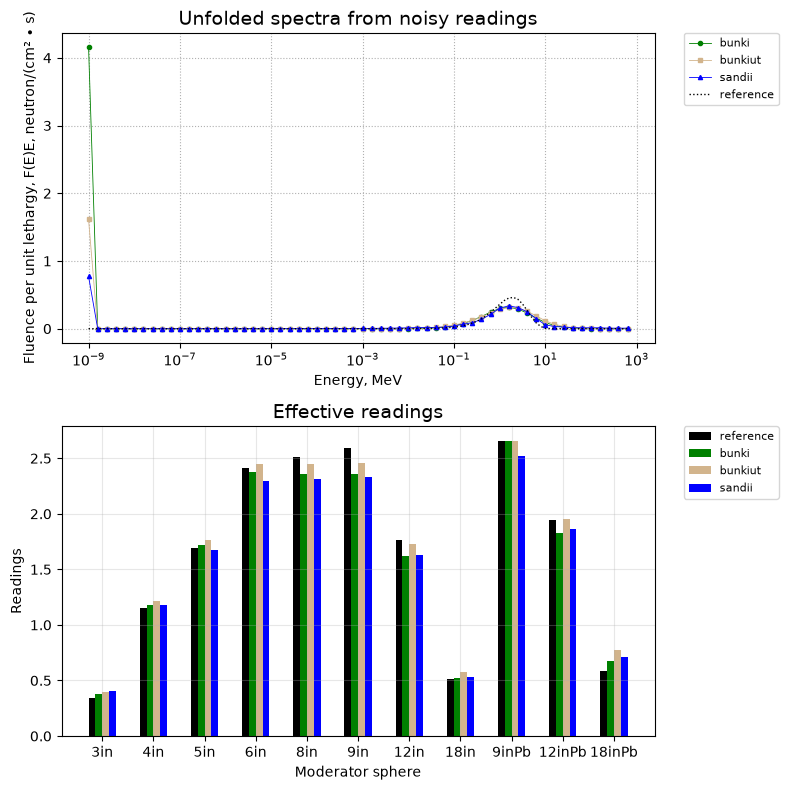

In [4]:
results = {
    "bunki": result_bunki,
    "bunkiut": result_bunkiut,
    "sandii": result_sandii,
}

fig, ax = plot_comparison(
    results=results,
    readings=readings,
    reference_spectrum=reference_spectrum[["E_MeV", "ISO_ref_Cf252"]],
)

## Calculate and display metrics

In [5]:
def calculate_metrics(unfolded, reference):
    """Calculate comparison metrics between unfolded and reference spectra."""
    unfolded_vals = unfolded.values
    ref_vals = reference.values
    
    # Normalized root mean square error
    nrmse = np.sqrt(np.mean((unfolded_vals - ref_vals)**2)) / np.mean(ref_vals) * 100
    
    # Mean absolute percentage error
    mape = np.mean(np.abs((ref_vals - unfolded_vals) / (ref_vals + 1e-10))) * 100
    
    # Integral quantity (total fluence)
    integral_unfolded = np.trapz(unfolded_vals, dx=1)
    integral_ref = np.trapz(ref_vals, dx=1)
    integral_ratio = integral_unfolded / integral_ref
    
    return {
        'NRMSE (%)': nrmse,
        'MAPE (%)': mape,
        'Integral Ratio': integral_ratio
    }

reference_values = reference_spectrum['ISO_ref_Cf252'].values
metrics_data = {}

for name, result in results.items():
    metrics_data[name] = calculate_metrics(result['spectrum'], reference_spectrum['ISO_ref_Cf252'])

metrics_df = pd.DataFrame(metrics_data).T
print("\nComparison Metrics:")
print(metrics_df.to_string())

AttributeError: 'numpy.ndarray' object has no attribute 'values'

## EURADOS integral-quantity comparison metrics

In [ ]:
from bssunfold.utils.metrics import calculate_dose_rates

# Calculate dose rates for EURADOS comparison
print("\nEURADOS Integral-Quantity Comparison:")
print("="*60)

ref_dose = calculate_dose_rates(reference_spectrum[['E_MeV','ISO_ref_Cf252']], det.E_MeV, det.RF)
print(f"Reference dose rate: {ref_dose:.4f} µSv/h")

for name, result in results.items():
    spectrum_df = pd.DataFrame({'E_MeV': det.E_MeV, 'flux': result['spectrum']})
    calc_dose = calculate_dose_rates(spectrum_df, det.E_MeV, det.RF)
    deviation = (calc_dose - ref_dose) / ref_dose * 100
    print(f"{name:20s}: {calc_dose:.4f} µSv/h (deviation: {deviation:+.2f}%)")

## Spectrum plots for each method

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

method_names = list(results.keys())

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(det.E_MeV, result['spectrum'], 'b-', label=f'{name}', linewidth=2)
    ax.plot(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'], 'r--', label='Reference', linewidth=2)
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Fluence')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

## Metrics histogram comparison

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics_df.index))
width = 0.25

ax.bar(x - width, metrics_df['NRMSE (%)'], width, label='NRMSE (%)')
ax.bar(x, metrics_df['MAPE (%)'], width, label='MAPE (%)')
ax.bar(x + width, np.abs(metrics_df['Integral Ratio'] - 1) * 100, width, label='Integral Deviation (%)')

ax.set_xlabel('Method')
ax.set_ylabel('Error (%)')
ax.set_title('Comparison Metrics Histogram')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated three iterative unfolding methods:

1. **Bunki**: Basic iterative unfolding approach
2. **BunkiUT**: Updated variant of the Bunki method
3. **Sandii**: Alternative iterative technique

These methods provide different approaches to solving the neutron spectrum unfolding problem through iterative refinement.